# Análisis de ventas — AdventureWorks2025

## 1. Carga y revisión de los datos

Carga de las tablas de órdenes, detalle de órdenes y productos utilizadas para el análisis.

In [2]:
import pandas as pd

# Lectura de datos
df_orders = pd.read_csv('../../data/SalesOrderHeader.csv', sep='\t', encoding='utf-8-sig', on_bad_lines='skip')
df_details = pd.read_csv('../../data/SalesOrderDetail.csv', sep='\t', encoding='utf-8-sig', on_bad_lines='skip')
df_products = pd.read_csv('../../data/Product.csv', sep='\t', encoding='utf-8-sig', on_bad_lines='skip')

# Limpieza rápida de espacios
df_orders.columns = df_orders.columns.str.strip()

# Verificación de desglose de columnas
print("Columnas de Orders:", df_orders.columns.tolist()[:5])
print("Dimensiones reales de Orders:", df_orders.shape)

Columnas de Orders: ['SalesOrderID', 'RevisionNumber', 'OrderDate', 'DueDate', 'ShipDate']
Dimensiones reales de Orders: (31465, 26)


In [4]:
print("SalesOrderHeader:", df_orders.shape)
print("SalesOrderDetail:", df_details.shape)
print("Product:", df_products.shape)

SalesOrderHeader: (31465, 26)
SalesOrderDetail: (121317, 11)
Product: (504, 25)


In [5]:
# Revisión de columnas principales
df_orders[['SalesOrderID', 'OrderDate', 'DueDate', 'ShipDate',
           'Status', 'OnlineOrderFlag', 'CustomerID', 'TotalDue']].head()

,SalesOrderID,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,CustomerID,TotalDue
0,43659,2022-05-30 00:00:00.000,2022-06-11 00:00:00.000,2022-06-06 00:00:00.000,5,0,29825,"23153,2339"
1,43660,2022-05-30 00:00:00.000,2022-06-11 00:00:00.000,2022-06-06 00:00:00.000,5,0,29672,"1457,3288"
2,43661,2022-05-30 00:00:00.000,2022-06-11 00:00:00.000,2022-06-06 00:00:00.000,5,0,29734,"36865,8012"
3,43662,2022-05-30 00:00:00.000,2022-06-11 00:00:00.000,2022-06-06 00:00:00.000,5,0,29994,"32474,9324"
4,43663,2022-05-30 00:00:00.000,2022-06-11 00:00:00.000,2022-06-06 00:00:00.000,5,0,29565,"472,3108"


In [6]:
# Tipos de datos de las columnas principales
df_orders[['OrderDate', 'DueDate', 'ShipDate', 'Status',
           'OnlineOrderFlag', 'TotalDue']].dtypes

OrderDate            str
DueDate              str
ShipDate             str
Status             int64
OnlineOrderFlag    int64
TotalDue             str
dtype: object

## 2. Preparación de los datos

Conversión de las columnas de fechas y ventas a los tipos de datos necesarios para realizar el análisis.

In [7]:
# Conversión de fechas
columnas_fecha = ['OrderDate', 'DueDate', 'ShipDate']

for columna in columnas_fecha:
    df_orders[columna] = pd.to_datetime(df_orders[columna])

# Conversión de TotalDue a valor numérico
df_orders['TotalDue'] = pd.to_numeric(
    df_orders['TotalDue'].str.replace(',', '.', regex=False)
)

In [8]:
df_orders[['OrderDate', 'DueDate', 'ShipDate', 'Status',
           'OnlineOrderFlag', 'TotalDue']].dtypes

OrderDate          datetime64[us]
DueDate            datetime64[us]
ShipDate           datetime64[us]
Status                      int64
OnlineOrderFlag             int64
TotalDue                  float64
dtype: object

In [9]:
# Validación de los datos
print("Valores nulos:")
print(df_orders[['OrderDate', 'DueDate', 'ShipDate', 'TotalDue']].isnull().sum())

print("\nÓrdenes por estado:")
print(df_orders['Status'].value_counts().sort_index())

print("\nRango de fechas:")
print("Desde:", df_orders['OrderDate'].min())
print("Hasta:", df_orders['OrderDate'].max())

Valores nulos:
OrderDate    0
DueDate      0
ShipDate     0
TotalDue     0
dtype: int64

Órdenes por estado:
Status
5    31465
Name: count, dtype: int64

Rango de fechas:
Desde: 2022-05-30 00:00:00
Hasta: 2025-06-29 00:00:00


## 3. Análisis general de ventas

Cálculo de los principales indicadores de ventas para conocer el comportamiento general de los datos.

In [10]:
ventas_totales = df_orders['TotalDue'].sum()
total_ordenes = df_orders['SalesOrderID'].nunique()
clientes_unicos = df_orders['CustomerID'].nunique()
ticket_promedio = ventas_totales / total_ordenes

print(f"Ventas totales: ${ventas_totales:,.2f}")
print(f"Total de órdenes: {total_ordenes:,}")
print(f"Clientes únicos: {clientes_unicos:,}")
print(f"Ticket promedio: ${ticket_promedio:,.2f}")

Ventas totales: $123,216,786.12
Total de órdenes: 31,465
Clientes únicos: 19,119
Ticket promedio: $3,916.00


### Comparación enero–mayo 2024 vs. 2025

Para comparar ambos años se utiliza el periodo enero–mayo, debido a que junio de 2025 contiene información parcial.

In [11]:
# Creación de año y mes
df_orders['Año'] = df_orders['OrderDate'].dt.year
df_orders['Mes'] = df_orders['OrderDate'].dt.month

# Periodo comparable: enero a mayo de 2024 y 2025
comparacion = df_orders[
    (df_orders['Año'].isin([2024, 2025])) &
    (df_orders['Mes'] <= 5)
]

resumen_comparacion = (
    comparacion
    .groupby('Año')
    .agg(
        Ventas=('TotalDue', 'sum'),
        Ordenes=('SalesOrderID', 'nunique')
    )
)

resumen_comparacion['TicketPromedio'] = (
    resumen_comparacion['Ventas'] / resumen_comparacion['Ordenes']
)

resumen_comparacion

,Ventas,Ordenes,TicketPromedio
Año,,,
2024,1.530915e+07,2043,7493.467202
2025,2.231242e+07,10794,2067.113357


In [12]:
variacion_ventas = (
    (resumen_comparacion.loc[2025, 'Ventas'] /
     resumen_comparacion.loc[2024, 'Ventas']) - 1
) * 100

variacion_ordenes = (
    (resumen_comparacion.loc[2025, 'Ordenes'] /
     resumen_comparacion.loc[2024, 'Ordenes']) - 1
) * 100

variacion_ticket = (
    (resumen_comparacion.loc[2025, 'TicketPromedio'] /
     resumen_comparacion.loc[2024, 'TicketPromedio']) - 1
) * 100

print(f"Variación de ventas: {variacion_ventas:.1f}%")
print(f"Variación de órdenes: {variacion_ordenes:.1f}%")
print(f"Variación del ticket promedio: {variacion_ticket:.1f}%")

Variación de ventas: 45.7%
Variación de órdenes: 428.3%
Variación del ticket promedio: -72.4%


### Resultado

Entre enero–mayo de 2024 y el mismo periodo de 2025, las ventas aumentaron 45.7% y el número de órdenes creció 428.3%.

Al mismo tiempo, el ticket promedio disminuyó 72.4%, lo que indica que el crecimiento de las ventas estuvo acompañado por un aumento mucho mayor en la cantidad de órdenes.

## 4. Análisis por canal

Comparación del comportamiento de las ventas, órdenes y ticket promedio entre el canal online y no online para enero–mayo de 2024 y 2025.

In [13]:
# Crear etiqueta de canal
comparacion = comparacion.copy()

comparacion['Canal'] = comparacion['OnlineOrderFlag'].map({
    1: 'Online',
    0: 'No online'
})

resumen_canal = (
    comparacion
    .groupby(['Año', 'Canal'])
    .agg(
        Ventas=('TotalDue', 'sum'),
        Ordenes=('SalesOrderID', 'nunique')
    )
)

resumen_canal['TicketPromedio'] = (
    resumen_canal['Ventas'] / resumen_canal['Ordenes']
)

resumen_canal

Ventas  Ordenes  TicketPromedio
Año  Canal                                           
2024 No online  1.236512e+07      511    24197.880824
     Online     2.944036e+06     1532     1921.694774
2025 No online  1.316752e+07      630    20900.827293
     Online     9.144900e+06    10164      899.734394

In [14]:
# Variaciones por canal entre 2024 y 2025

online_2024 = resumen_canal.loc[(2024, 'Online')]
online_2025 = resumen_canal.loc[(2025, 'Online')]

no_online_2024 = resumen_canal.loc[(2024, 'No online')]
no_online_2025 = resumen_canal.loc[(2025, 'No online')]

print("Canal Online")
print(f"Ventas: {(online_2025['Ventas'] / online_2024['Ventas'] - 1) * 100:.1f}%")
print(f"Órdenes: {(online_2025['Ordenes'] / online_2024['Ordenes'] - 1) * 100:.1f}%")
print(f"Ticket promedio: {(online_2025['TicketPromedio'] / online_2024['TicketPromedio'] - 1) * 100:.1f}%")

print("\nCanal No online")
print(f"Ventas: {(no_online_2025['Ventas'] / no_online_2024['Ventas'] - 1) * 100:.1f}%")
print(f"Órdenes: {(no_online_2025['Ordenes'] / no_online_2024['Ordenes'] - 1) * 100:.1f}%")
print(f"Ticket promedio: {(no_online_2025['TicketPromedio'] / no_online_2024['TicketPromedio'] - 1) * 100:.1f}%")

Canal Online
Ventas: 210.6%
Órdenes: 563.4%
Ticket promedio: -53.2%

Canal No online
Ventas: 6.5%
Órdenes: 23.3%
Ticket promedio: -13.6%


### Resultado

Entre enero–mayo de 2024 y en el mismo periodo de 2025, el canal online presentó un crecimiento mucho mayor:

- Ventas online: +210.6%
- Órdenes online: +563.4%
- Ticket promedio online: -53.2%

En el canal no online:

- Ventas: +6.5%
- Órdenes: +23.3%
- Ticket promedio: -13.6%

El crecimiento de las órdenes estuvo concentrado principalmente en el canal online, pero con una reducción importante del ticket promedio.

## 5. Análisis de productos

Análisis de la participación de los productos con mayores ventas y la concentración de ventas en la línea Mountain-200.

In [17]:
# Preparación de detalle de ventas
df_details['LineTotal'] = pd.to_numeric(df_details['LineTotal'])

detalle_productos = df_details.merge(
    df_products[['ProductID', 'Name']],
    on='ProductID',
    how='left'
)

In [18]:
ventas_producto = (
    detalle_productos
    .groupby('Name', as_index=False)['LineTotal']
    .sum()
    .sort_values('LineTotal', ascending=False)
)

top_10_productos = ventas_producto.head(10)

top_10_productos

,Name,LineTotal
153,"Mountain-200 Black, 38",4.400593e+06
154,"Mountain-200 Black, 42",4.009495e+06
156,"Mountain-200 Silver, 38",3.693678e+06
157,"Mountain-200 Silver, 42",3.438479e+06
158,"Mountain-200 Silver, 46",3.434257e+06
155,"Mountain-200 Black, 46",3.309673e+06
189,"Road-250 Black, 44",2.516857e+06
190,"Road-250 Black, 48",2.347656e+06
191,"Road-250 Black, 52",2.012448e+06
187,"Road-150 Red, 56",1.847819e+06


In [19]:
# Concentración de ventas en productos principales

ventas_totales_productos = ventas_producto['LineTotal'].sum()

ventas_mountain_200 = ventas_producto[
    ventas_producto['Name'].str.startswith('Mountain-200')
]['LineTotal'].sum()

ventas_top_10 = top_10_productos['LineTotal'].sum()

participacion_mountain_200 = (
    ventas_mountain_200 / ventas_totales_productos
) * 100

participacion_top_10 = (
    ventas_top_10 / ventas_totales_productos
) * 100

print(f"Ventas Mountain-200: ${ventas_mountain_200:,.2f}")
print(f"Participación Mountain-200: {participacion_mountain_200:.1f}%")

print(f"\nVentas Top 10 productos: ${ventas_top_10:,.2f}")
print(f"Participación Top 10 productos: {participacion_top_10:.1f}%")

Ventas Mountain-200: $22,286,174.61
Participación Mountain-200: 20.3%

Ventas Top 10 productos: $31,010,954.28
Participación Top 10 productos: 28.2%


### Resultado

Los seis modelos Mountain-200 aparecen entre los productos con mayores ventas y, en conjunto, representan aproximadamente el 20.3% del LineTotal.
Además, los 10 productos con mayores ventas concentran aproximadamente el 28.2% del LineTotal.
Esto muestra que una parte importante de las ventas está concentrada en un grupo reducido de productos.

## 6. Evolución mensual de ventas

Análisis de la evolución de las ventas por mes durante el periodo disponible.

In [20]:
ventas_mensuales = (
    df_orders
    .groupby(df_orders['OrderDate'].dt.to_period('M'))['TotalDue']
    .sum()
    .reset_index()
)

ventas_mensuales['OrderDate'] = ventas_mensuales['OrderDate'].dt.to_timestamp()

ventas_mensuales

,OrderDate,TotalDue
0,2022-05-01,5.824153e+05
1,2022-06-01,2.244313e+06
2,2022-07-01,1.868508e+06
3,2022-08-01,1.483277e+06
4,2022-09-01,3.183714e+06
5,2022-10-01,2.543935e+06
6,2022-11-01,1.603314e+06
7,2022-12-01,2.807217e+06
8,2023-01-01,2.325569e+06
9,2023-02-01,1.620826e+06


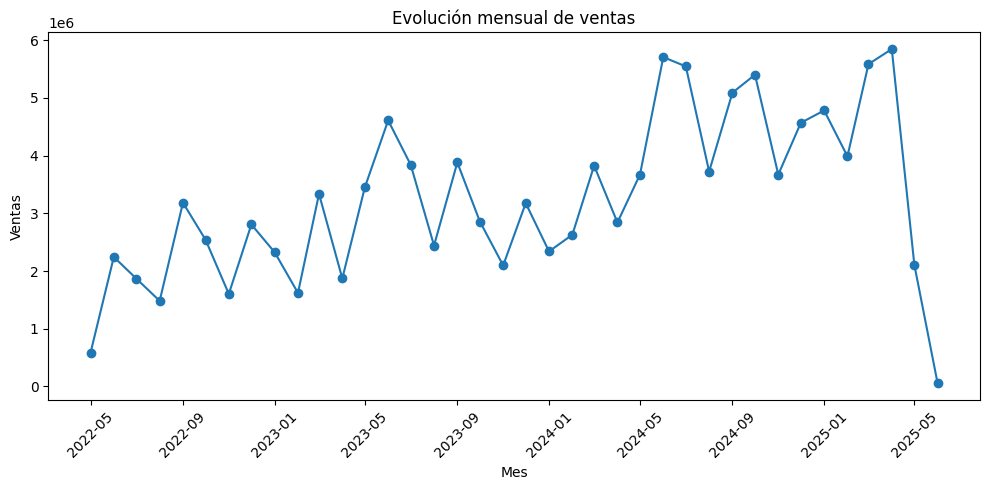

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    ventas_mensuales['OrderDate'],
    ventas_mensuales['TotalDue'],
    marker='o'
)

plt.title('Evolución mensual de ventas')
plt.xlabel('Mes')
plt.ylabel('Ventas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> **Nota:** junio de 2025 contiene información parcial, por lo que su valor no debe compararse directamente con meses completos.